<a href="https://colab.research.google.com/github/Nandana-S30/Static-webpage/blob/main/Dynamic_Semantic_Resume_Parser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 5.7 MB/s eta 0:00:00
Please upload PDF resumes (you can select multiple files at once):


Saving Nandana_S_ATS_Final (1).pdf to Nandana_S_ATS_Final (1).pdf
✅ Successfully parsed: Nandana_S_ATS_Final (1).pdf

Loading AI Embedding Model (this takes a few seconds)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating semantic vector spaces...

--- DYNAMIC SEMANTIC RANKING REPORT ---
             Candidate_File  Semantic_Match_Score
Nandana_S_ATS_Final (1).pdf             37.259998


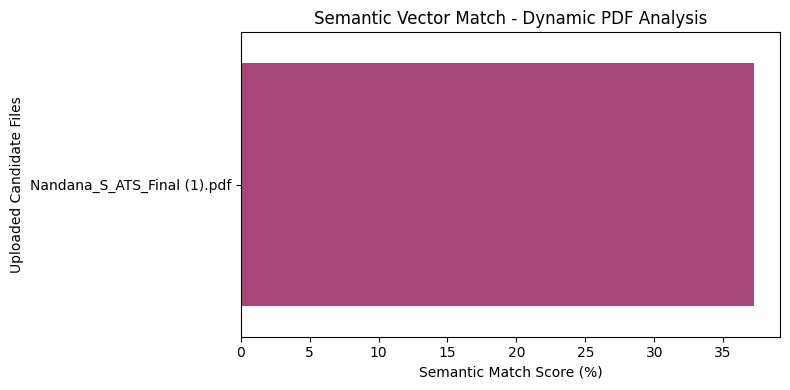

In [1]:
# 1. Install required libraries for dynamic PDF reading and NLP
!pip install -q PyPDF2 sentence-transformers pandas matplotlib seaborn

import os
import io
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PyPDF2 import PdfReader
from sentence_transformers import SentenceTransformer, util
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# 2. Define the Target Job Description
job_description = """
Seeking a Data Analyst or Scientist proficient in Python, predictive modeling,
and automated data cleaning pipelines. Must understand machine learning validation
and have experience with modern NLP or vector search algorithms.
"""

# 3. Dynamic File Ingestion (Triggers the upload button)
print("Please upload PDF resumes (you can select multiple files at once):")
uploaded = files.upload()

# 4. Extract Text from Uploaded PDFs
resume_data = []
for filename, content in uploaded.items():
    if filename.endswith('.pdf'):
        reader = PdfReader(io.BytesIO(content))
        text = ""
        for page in reader.pages:
            text += page.extract_text() + " "
        resume_data.append({"Candidate_File": filename, "Resume_Text": text.strip()})
        print(f"✅ Successfully parsed: {filename}")

if not resume_data:
    print("No PDFs were uploaded. Please try again.")
else:
    df = pd.DataFrame(resume_data)

    # 5. Load the Sentence Transformer Model (Semantic AI)
    print("\nLoading AI Embedding Model (this takes a few seconds)...")
    model = SentenceTransformer('all-MiniLM-L6-v2')

    # 6. Generate Semantic Embeddings
    print("Generating semantic vector spaces...")
    jd_embedding = model.encode(job_description, convert_to_tensor=True)
    resume_embeddings = model.encode(df['Resume_Text'].tolist(), convert_to_tensor=True)

    # 7. Calculate Cosine Similarity over the Vector Space
    similarity_scores = util.cos_sim(jd_embedding, resume_embeddings)[0].cpu().numpy()

    # 8. Format and Display the Output
    df['Semantic_Match_Score'] = (similarity_scores * 100).round(2)
    df = df.sort_values(by='Semantic_Match_Score', ascending=False)

    print("\n--- DYNAMIC SEMANTIC RANKING REPORT ---")
    print(df[['Candidate_File', 'Semantic_Match_Score']].to_string(index=False))

    # 9. Visualization
    plt.figure(figsize=(8, 4))
    sns.barplot(x='Semantic_Match_Score', y='Candidate_File', data=df, palette='magma')
    plt.title('Semantic Vector Match - Dynamic PDF Analysis')
    plt.xlabel('Semantic Match Score (%)')
    plt.ylabel('Uploaded Candidate Files')
    plt.tight_layout()
    plt.show()